# Credit Card Fraud Detection - Tree-Based Models
This notebook contains the implementation, evaluation, and threshold tuning of the Random Forest and Gradient Boosted Trees models. It specifically utilizes Synthetic Minority Over-sampling Technique (SMOTE) to address the extreme class imbalance in the dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('creditcard.csv')

scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)
scaled_amount = df.pop('Scaled_Amount')
scaled_time = df.pop('Scaled_Time')
df.insert(0, 'Scaled_Time', scaled_time)
df.insert(1, 'Scaled_Amount', scaled_amount)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Fraud cases in training: {sum(y_train == 1)}")

Training set shape: (227845, 30)
Test set shape: (56962, 30)
Fraud cases in training: 394


In [ ]:
print("Training Standard Random Forest on raw imbalanced data...")
rf_base_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_base_model.fit(X_train, y_train)

print("Training Standard Gradient Boosted Trees on raw imbalanced data...")
gbt_base_model = HistGradientBoostingClassifier(max_iter=100, max_depth=10, random_state=42)
gbt_base_model.fit(X_train, y_train)

rf_base_probs = rf_base_model.predict_proba(X_test)[:, 1]
gbt_base_probs = gbt_base_model.predict_proba(X_test)[:, 1]

rf_base_precision, rf_base_recall, _ = precision_recall_curve(y_test, rf_base_probs)
rf_base_pr_auc = auc(rf_base_recall, rf_base_precision)

gbt_base_precision, gbt_base_recall, _ = precision_recall_curve(y_test, gbt_base_probs)
gbt_base_pr_auc = auc(gbt_base_recall, gbt_base_precision)

print(f"Base Random Forest PR-AUC: {rf_base_pr_auc:.4f}")
print(f"Base Gradient Boosted Trees PR-AUC: {gbt_base_pr_auc:.4f}")

Training Standard Random Forest on raw imbalanced data...
Training Standard Gradient Boosted Trees on raw imbalanced data...
Base Random Forest PR-AUC: 0.8629
Base Gradient Boosted Trees PR-AUC: 0.7110


In [4]:
print("Before SMOTE, counts of label '1': {}".format(sum(y_train == 1)))
print("Before SMOTE, counts of label '0': {} \n".format(sum(y_train == 0)))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE, counts of label '1': {}".format(sum(y_train_smote == 1)))
print("After SMOTE, counts of label '0': {}".format(sum(y_train_smote == 0)))

Before SMOTE, counts of label '1': 394
Before SMOTE, counts of label '0': 227451 

After SMOTE, counts of label '1': 227451
After SMOTE, counts of label '0': 227451


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

print("Training Random Forest on SMOTE data...")
rf_model.fit(X_train_smote, y_train_smote)
print("Random Forest training complete.")

Training Random Forest on SMOTE data...
Random Forest training complete.


In [6]:
gbt_model = HistGradientBoostingClassifier(max_iter=100, max_depth=10, random_state=42)

print("Training Gradient Boosted Trees on SMOTE data...")
gbt_model.fit(X_train_smote, y_train_smote)
print("GBT training complete.")

Training Gradient Boosted Trees on SMOTE data...
GBT training complete.


In [7]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
gbt_probs = gbt_model.predict_proba(X_test)[:, 1]

rf_preds = rf_model.predict(X_test)
gbt_preds = gbt_model.predict(X_test)

rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)
rf_pr_auc = auc(rf_recall, rf_precision)

gbt_precision, gbt_recall, _ = precision_recall_curve(y_test, gbt_probs)
gbt_pr_auc = auc(gbt_recall, gbt_precision)

print(f"Random Forest PR-AUC: {rf_pr_auc:.4f}")
print(f"Gradient Boosted Trees PR-AUC: {gbt_pr_auc:.4f}")

Random Forest PR-AUC: 0.8098
Gradient Boosted Trees PR-AUC: 0.8136


Updated Tree PR-Curve saved!


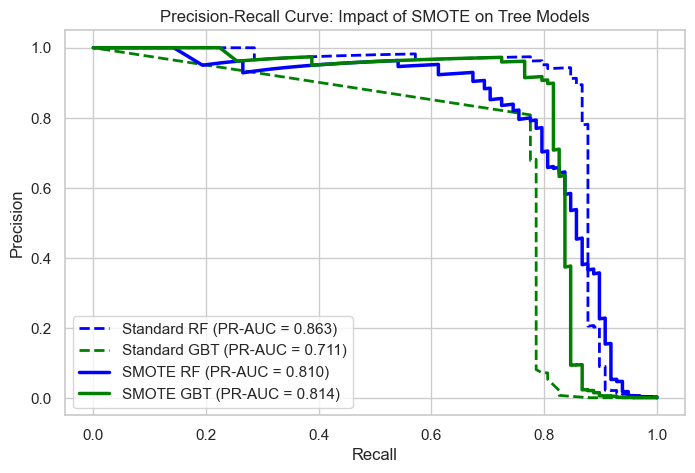

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(rf_base_recall, rf_base_precision, label=f'Standard RF (PR-AUC = {rf_base_pr_auc:.3f})', color='blue', linestyle='--', lw=2)
plt.plot(gbt_base_recall, gbt_base_precision, label=f'Standard GBT (PR-AUC = {gbt_base_pr_auc:.3f})', color='green', linestyle='--', lw=2)

plt.plot(rf_recall, rf_precision, label=f'SMOTE RF (PR-AUC = {rf_pr_auc:.3f})', color='blue', lw=2.5)
plt.plot(gbt_recall, gbt_precision, label=f'SMOTE GBT (PR-AUC = {gbt_pr_auc:.3f})', color='green', lw=2.5)

plt.title('Precision-Recall Curve: Impact of SMOTE on Tree Models')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')

plt.savefig('tm_tree_models_pr_curve.png', dpi=300, bbox_inches='tight')
print("Updated Tree PR-Curve saved!")
plt.show()

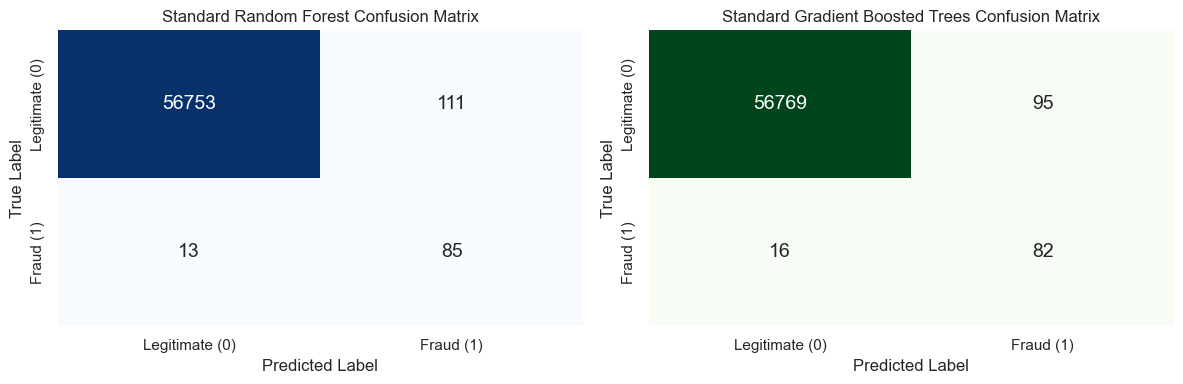

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.87      0.58        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962


--- Gradient Boosted Trees Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.84      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.92      0.80     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rf_cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Standard Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].xaxis.set_ticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[0].yaxis.set_ticklabels(['Legitimate (0)', 'Fraud (1)'])

gbt_cm = confusion_matrix(y_test, gbt_preds)
sns.heatmap(gbt_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title('Standard Gradient Boosted Trees Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].xaxis.set_ticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1].yaxis.set_ticklabels(['Legitimate (0)', 'Fraud (1)'])

plt.tight_layout()
plt.savefig('tm_standard_tree_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_preds))
print("\n--- Gradient Boosted Trees Classification Report ---")
print(classification_report(y_test, gbt_preds))

Default 0.5 Threshold F1-Score: 0.5782
Optimal Threshold: 0.8196 (Yields F1-Score: 0.7897)


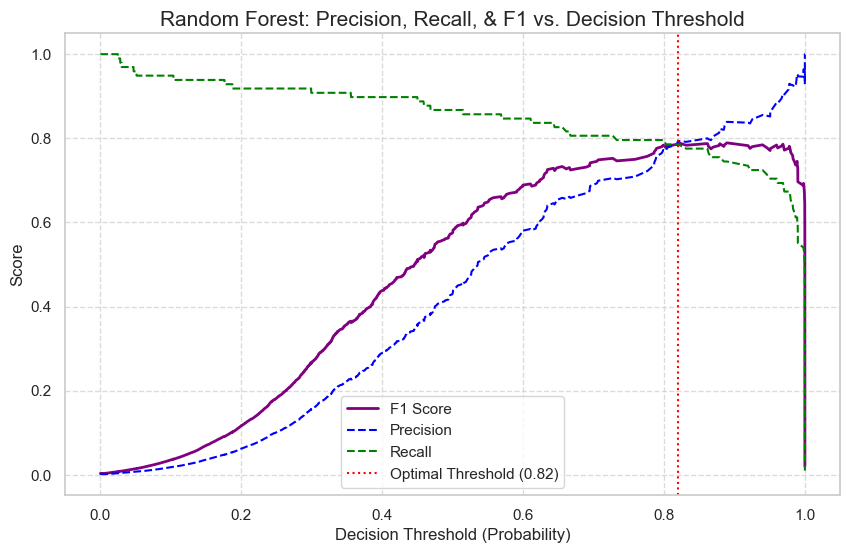

In [10]:
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(y_test, rf_probs)

rf_f1_scores = 2 * (rf_precision[:-1] * rf_recall[:-1]) / (rf_precision[:-1] + rf_recall[:-1])

optimal_idx = np.argmax(rf_f1_scores)
optimal_threshold = rf_thresholds[optimal_idx]
best_f1 = rf_f1_scores[optimal_idx]

print(f"Default 0.5 Threshold F1-Score: {2 * (rf_precision[np.searchsorted(rf_thresholds, 0.5)] * rf_recall[np.searchsorted(rf_thresholds, 0.5)]) / (rf_precision[np.searchsorted(rf_thresholds, 0.5)] + rf_recall[np.searchsorted(rf_thresholds, 0.5)]):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f} (Yields F1-Score: {best_f1:.4f})")

plt.figure(figsize=(10, 6))
plt.plot(rf_thresholds, rf_f1_scores, label='F1 Score', color='purple', lw=2)
plt.plot(rf_thresholds, rf_precision[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(rf_thresholds, rf_recall[:-1], label='Recall', color='green', linestyle='--')

plt.axvline(x=optimal_threshold, color='red', linestyle=':', 
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('Random Forest: Precision, Recall, & F1 vs. Decision Threshold', fontsize=15)
plt.xlabel('Decision Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('tm_rf_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
smote_lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression on SMOTE data...")
smote_lr_model.fit(X_train_smote, y_train_smote)
print("SMOTE Logistic Regression training complete.")

Training Logistic Regression on SMOTE data...
SMOTE Logistic Regression training complete.


In [12]:
smote_lr_probs = smote_lr_model.predict_proba(X_test)[:, 1]
smote_lr_preds = smote_lr_model.predict(X_test)

smote_lr_precision, smote_lr_recall, smote_lr_thresholds = precision_recall_curve(y_test, smote_lr_probs)
smote_lr_pr_auc = auc(smote_lr_recall, smote_lr_precision)

print(f"SMOTE Logistic Regression PR-AUC: {smote_lr_pr_auc:.4f}")

print("\n--- SMOTE Logistic Regression Classification Report ---")
print(classification_report(y_test, smote_lr_preds))

SMOTE Logistic Regression PR-AUC: 0.7703

--- SMOTE Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



Default 0.5 Threshold F1-Score: 0.5964
Optimal Threshold: 0.9529 (Yields F1-Score: 0.8556)


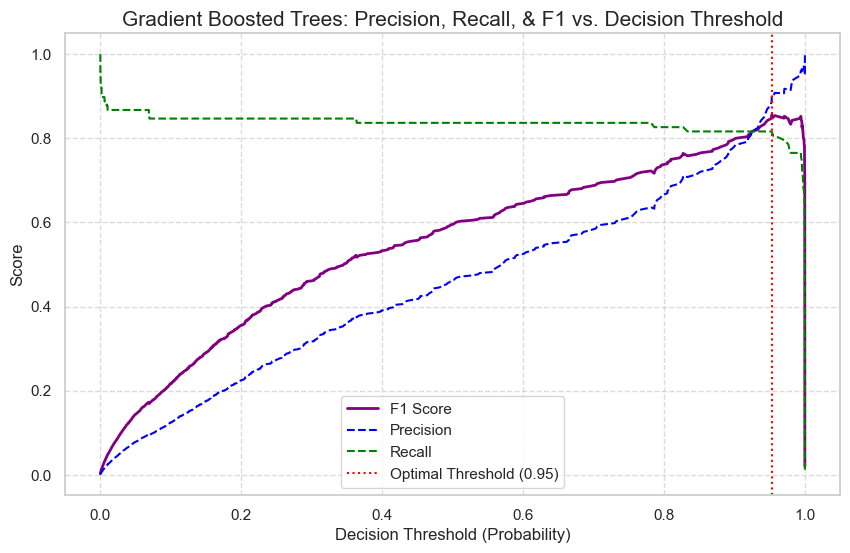

In [13]:
gbt_precision_array, gbt_recall_array, gbt_thresholds = precision_recall_curve(y_test, gbt_probs)

gbt_f1_scores = 2 * (gbt_precision_array[:-1] * gbt_recall_array[:-1]) / (gbt_precision_array[:-1] + gbt_recall_array[:-1])

gbt_optimal_idx = np.argmax(gbt_f1_scores)
gbt_optimal_threshold = gbt_thresholds[gbt_optimal_idx]
gbt_best_f1 = gbt_f1_scores[gbt_optimal_idx]

gbt_default_idx = np.searchsorted(gbt_thresholds, 0.5)
gbt_default_f1 = 2 * (gbt_precision_array[gbt_default_idx] * gbt_recall_array[gbt_default_idx]) / (gbt_precision_array[gbt_default_idx] + gbt_recall_array[gbt_default_idx])

print(f"Default 0.5 Threshold F1-Score: {gbt_default_f1:.4f}")
print(f"Optimal Threshold: {gbt_optimal_threshold:.4f} (Yields F1-Score: {gbt_best_f1:.4f})")

plt.figure(figsize=(10, 6))
plt.plot(gbt_thresholds, gbt_f1_scores, label='F1 Score', color='purple', lw=2)
plt.plot(gbt_thresholds, gbt_precision_array[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(gbt_thresholds, gbt_recall_array[:-1], label='Recall', color='green', linestyle='--')

plt.axvline(x=gbt_optimal_threshold, color='red', linestyle=':', 
            label=f'Optimal Threshold ({gbt_optimal_threshold:.2f})')

plt.title('Gradient Boosted Trees: Precision, Recall, & F1 vs. Decision Threshold', fontsize=15)
plt.xlabel('Decision Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('tm_gbt_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

Calculating GBT permutation importances...
Feature importances plotted and saved!


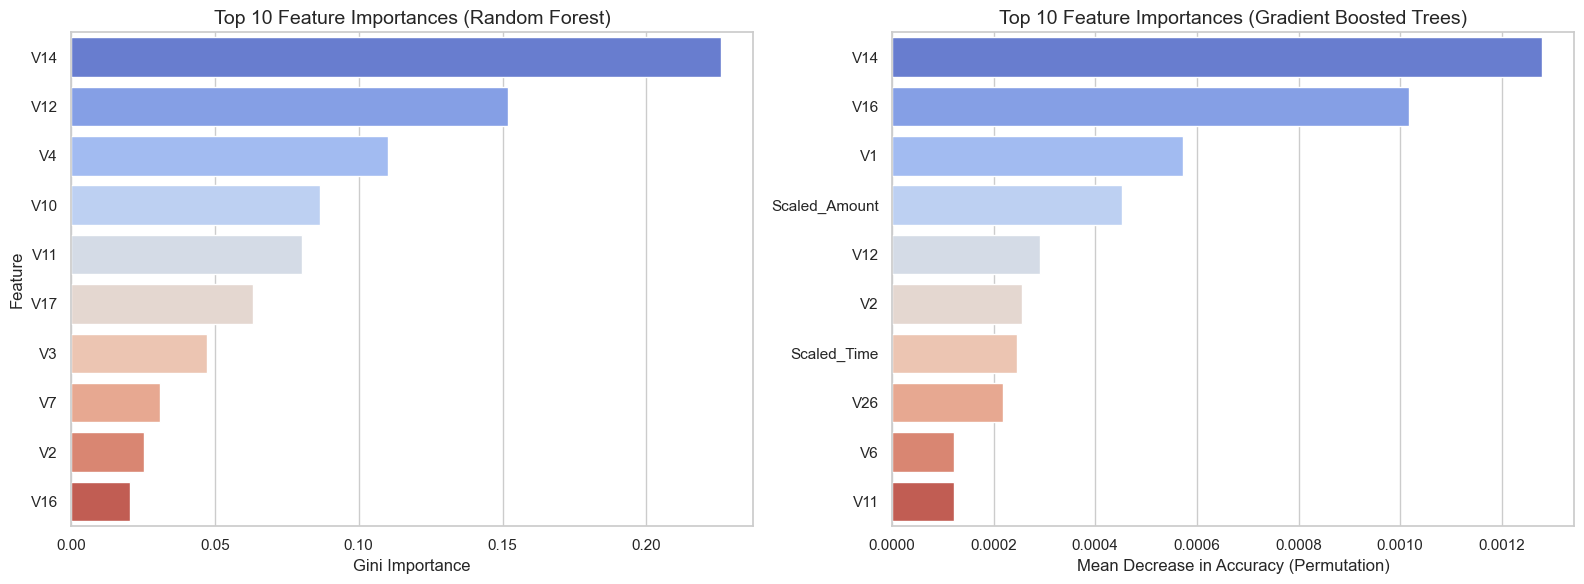

In [14]:
rf_importances = rf_model.feature_importances_
rf_feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_importances})
rf_feat_imp_df = rf_feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

print("Calculating GBT permutation importances...")
gbt_perm_imp = permutation_importance(gbt_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
gbt_feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': gbt_perm_imp.importances_mean})
gbt_feat_imp_df = gbt_feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Importance', y='Feature', data=rf_feat_imp_df, ax=axes[0], palette='coolwarm', hue='Feature', legend=False)
axes[0].set_title('Top 10 Feature Importances (Random Forest)', fontsize=14)
axes[0].set_xlabel('Gini Importance', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)

sns.barplot(x='Importance', y='Feature', data=gbt_feat_imp_df, ax=axes[1], palette='coolwarm', hue='Feature', legend=False)
axes[1].set_title('Top 10 Feature Importances (Gradient Boosted Trees)', fontsize=14)
axes[1].set_xlabel('Mean Decrease in Accuracy (Permutation)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('tm_tree_feature_importances.png', dpi=300, bbox_inches='tight')
print("Feature importances plotted and saved!")
plt.show()

--- OPTIMIZED RANDOM FOREST ---
Optimal Threshold: 0.8196
Optimized Precision: 0.7938
Optimized Recall:    0.7857
Optimized F1-Score:  0.7897

--- OPTIMIZED GRADIENT BOOSTED TREES ---
Optimal Threshold: 0.9529
Optimized Precision: 0.8989
Optimized Recall:    0.8163
Optimized F1-Score:  0.8556

Optimized Labeled Confusion Matrices saved!


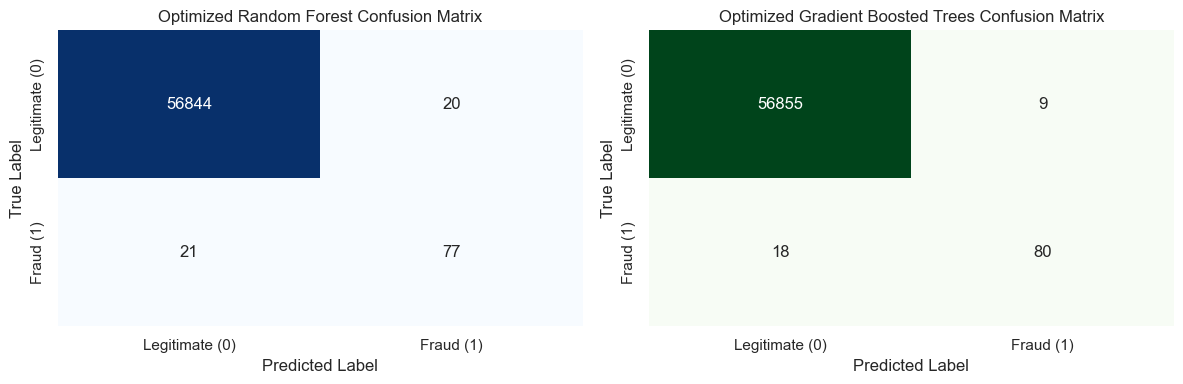

In [15]:
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(y_test, rf_probs)
rf_f1_scores = 2 * (rf_precision[:-1] * rf_recall[:-1]) / (rf_precision[:-1] + rf_recall[:-1] + 1e-8)
rf_opt_idx = np.argmax(rf_f1_scores)
rf_optimal_threshold = rf_thresholds[rf_opt_idx]

gbt_precision, gbt_recall, gbt_thresholds = precision_recall_curve(y_test, gbt_probs)
gbt_f1_scores = 2 * (gbt_precision[:-1] * gbt_recall[:-1]) / (gbt_precision[:-1] + gbt_recall[:-1] + 1e-8)
gbt_opt_idx = np.argmax(gbt_f1_scores)
gbt_optimal_threshold = gbt_thresholds[gbt_opt_idx]

print("--- OPTIMIZED RANDOM FOREST ---")
print(f"Optimal Threshold: {rf_optimal_threshold:.4f}")
print(f"Optimized Precision: {rf_precision[rf_opt_idx]:.4f}")
print(f"Optimized Recall:    {rf_recall[rf_opt_idx]:.4f}")
print(f"Optimized F1-Score:  {rf_f1_scores[rf_opt_idx]:.4f}\n")

print("--- OPTIMIZED GRADIENT BOOSTED TREES ---")
print(f"Optimal Threshold: {gbt_optimal_threshold:.4f}")
print(f"Optimized Precision: {gbt_precision[gbt_opt_idx]:.4f}")
print(f"Optimized Recall:    {gbt_recall[gbt_opt_idx]:.4f}")
print(f"Optimized F1-Score:  {gbt_f1_scores[gbt_opt_idx]:.4f}\n")

optimal_rf_preds = (rf_probs >= rf_optimal_threshold).astype(int)
optimal_gbt_preds = (gbt_probs >= gbt_optimal_threshold).astype(int)

cm_rf_opt = confusion_matrix(y_test, optimal_rf_preds)
cm_gbt_opt = confusion_matrix(y_test, optimal_gbt_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_rf_opt, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'], yticklabels=['Legitimate (0)', 'Fraud (1)'])
axes[0].set_title(f'Optimized Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_gbt_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'], yticklabels=['Legitimate (0)', 'Fraud (1)'])
axes[1].set_title(f'Optimized Gradient Boosted Trees Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('tm_optimized_tree_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("Optimized Labeled Confusion Matrices saved!")
plt.show()

In [ ]:
rf_base_preds = (rf_base_probs >= 0.5).astype(int)
gbt_base_preds = (gbt_base_probs >= 0.5).astype(int)

rf_base_prec_array, rf_base_rec_array, _ = precision_recall_curve(y_test, rf_base_probs)
rf_base_pr_auc = auc(rf_base_rec_array, rf_base_prec_array)
rf_base_cm = confusion_matrix(y_test, rf_base_preds)

gbt_base_prec_array, gbt_base_rec_array, _ = precision_recall_curve(y_test, gbt_base_probs)
gbt_base_pr_auc = auc(gbt_base_rec_array, gbt_base_prec_array)
gbt_base_cm = confusion_matrix(y_test, gbt_base_preds)

print("--- STANDARD RANDOM FOREST ---")
print(f"Default Threshold: 0.5000")
print(f"PR-AUC:            {rf_base_pr_auc:.4f}")
print(f"F1-Score:          {f1_score(y_test, rf_base_preds):.4f}")
print(f"Precision:         {precision_score(y_test, rf_base_preds):.4f}")
print(f"Recall:            {recall_score(y_test, rf_base_preds):.4f}")
print(f"True Positives:    {rf_base_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {rf_base_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {rf_base_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {rf_base_cm[0, 0]} (Legit)")
print("------------------------------\n")

print("--- STANDARD GRADIENT BOOSTED TREES ---")
print(f"Default Threshold: 0.5000")
print(f"PR-AUC:            {gbt_base_pr_auc:.4f}")
print(f"F1-Score:          {f1_score(y_test, gbt_base_preds):.4f}")
print(f"Precision:         {precision_score(y_test, gbt_base_preds):.4f}")
print(f"Recall:            {recall_score(y_test, gbt_base_preds):.4f}")
print(f"True Positives:    {gbt_base_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {gbt_base_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {gbt_base_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {gbt_base_cm[0, 0]} (Legit)")
print("---------------------------------------\n")

--- STANDARD RANDOM FOREST ---
Default Threshold: 0.5000
PR-AUC:            0.8629
F1-Score:          0.8804
Precision:         0.9419
Recall:            0.8265
True Positives:    81 (Fraud)
False Negatives:   17 (Fraud but classified legit)
False Positives:   5 (Legit but classified fraud)
True Negatives:    56859 (Legit)
------------------------------

--- STANDARD GRADIENT BOOSTED TREES ---
Default Threshold: 0.5000
PR-AUC:            0.7110
F1-Score:          0.5768
Precision:         0.4556
Recall:            0.7857
True Positives:    77 (Fraud)
False Negatives:   21 (Fraud but classified legit)
False Positives:   92 (Legit but classified fraud)
True Negatives:    56772 (Legit)
---------------------------------------



In [ ]:
rf_prec_array, rf_rec_array, rf_thresh = precision_recall_curve(y_test, rf_probs)
rf_f1_scores = 2 * (rf_prec_array[:-1] * rf_rec_array[:-1]) / (rf_prec_array[:-1] + rf_rec_array[:-1] + 1e-8)
rf_opt_idx = np.argmax(rf_f1_scores)
rf_opt_thresh = rf_thresh[rf_opt_idx]
rf_opt_preds = (rf_probs >= rf_opt_thresh).astype(int)
rf_cm = confusion_matrix(y_test, rf_opt_preds)

gbt_prec_array, gbt_rec_array, gbt_thresh = precision_recall_curve(y_test, gbt_probs)
gbt_f1_scores = 2 * (gbt_prec_array[:-1] * gbt_rec_array[:-1]) / (gbt_prec_array[:-1] + gbt_rec_array[:-1] + 1e-8)
gbt_opt_idx = np.argmax(gbt_f1_scores)
gbt_opt_thresh = gbt_thresh[gbt_opt_idx]
gbt_opt_preds = (gbt_probs >= gbt_opt_thresh).astype(int)
gbt_cm = confusion_matrix(y_test, gbt_opt_preds)

print("--- SMOTE RANDOM FOREST (OPTIMIZED) ---")
print(f"Optimal Threshold: {rf_opt_thresh:.4f}")
print(f"PR-AUC:            {auc(rf_rec_array, rf_prec_array):.4f}")
print(f"F1-Score:          {f1_score(y_test, rf_opt_preds):.4f}")
print(f"Precision:         {precision_score(y_test, rf_opt_preds):.4f}")
print(f"Recall:            {recall_score(y_test, rf_opt_preds):.4f}")
print(f"True Positives:    {rf_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {rf_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {rf_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {rf_cm[0, 0]} (Legit)")
print("---------------------------------------\n")

print("--- SMOTE GRADIENT BOOSTED TREES (OPTIMIZED) ---")
print(f"Optimal Threshold: {gbt_opt_thresh:.4f}")
print(f"PR-AUC:            {auc(gbt_rec_array, gbt_prec_array):.4f}")
print(f"F1-Score:          {f1_score(y_test, gbt_opt_preds):.4f}")
print(f"Precision:         {precision_score(y_test, gbt_opt_preds):.4f}")
print(f"Recall:            {recall_score(y_test, gbt_opt_preds):.4f}")
print(f"True Positives:    {gbt_cm[1, 1]} (Fraud)")
print(f"False Negatives:   {gbt_cm[1, 0]} (Fraud but classified legit)")
print(f"False Positives:   {gbt_cm[0, 1]} (Legit but classified fraud)")
print(f"True Negatives:    {gbt_cm[0, 0]} (Legit)")
print("------------------------------------------------")

--- SMOTE RANDOM FOREST (OPTIMIZED) ---
Optimal Threshold: 0.8196
PR-AUC:            0.8098
F1-Score:          0.7897
Precision:         0.7938
Recall:            0.7857
True Positives:    77 (Fraud)
False Negatives:   21 (Fraud but classified legit)
False Positives:   20 (Legit but classified fraud)
True Negatives:    56844 (Legit)
---------------------------------------

--- SMOTE GRADIENT BOOSTED TREES (OPTIMIZED) ---
Optimal Threshold: 0.9529
PR-AUC:            0.8136
F1-Score:          0.8556
Precision:         0.8989
Recall:            0.8163
True Positives:    80 (Fraud)
False Negatives:   18 (Fraud but classified legit)
False Positives:   9 (Legit but classified fraud)
True Negatives:    56855 (Legit)
------------------------------------------------


In [ ]:
np.savez('tree_predictions.npz', 
         y_test=y_test, 
         smote_lr=smote_lr_probs,
         rf_base=rf_base_probs,      
         gbt_base=gbt_base_probs,    
         rf=rf_probs,                
         gbt=gbt_probs)              
print("All tree predictions saved successfully!")

All tree predictions saved successfully!
